# Proyecto de Grado: Priorizacion de Mantenimiento Predictivo para Fallas APS en Camiones Scania

Este notebook implementa el flujo metodologico principal del proyecto con una arquitectura mas robusta:

1. limpieza y caracterizacion de datos
2. analisis exploratorio orientado a decisiones metodologicas
3. seleccion de caracteristicas basada en machine learning
4. comparacion de modelos con y sin tratamiento explicito del desbalance
5. validacion cruzada estratificada
6. seleccion de umbral por costo
7. validacion final en el conjunto oficial de prueba
8. generacion de salida de priorizacion para una capa de aplicacion


## 1. Configuracion e importaciones

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('imblearn') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn'])

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
REPORTS_DIR = PROJECT_ROOT / 'reports' / 'scania_project'
FIGURES_DIR = REPORTS_DIR / 'figures'
TABLES_DIR = REPORTS_DIR / 'tables'
MODELS_DIR = PROJECT_ROOT / 'models'

for directory in [REPORTS_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DIR / 'aps_failure_training_set.csv'
TEST_PATH = RAW_DIR / 'aps_failure_test_set.csv'
TARGET_COLUMN = 'class'
POSITIVE_LABEL = 'pos'
NEGATIVE_LABEL = 'neg'
RANDOM_STATE = 42
FALSE_POSITIVE_COST = 10
FALSE_NEGATIVE_COST = 500
TOP_K_FEATURES = 30
N_SPLITS = 5

TRAIN_PATH, TEST_PATH

(WindowsPath('C:/Users/geral/Documents/Trabajo de Grado/complaints_thesis/data/raw/aps_failure_training_set.csv'),
 WindowsPath('C:/Users/geral/Documents/Trabajo de Grado/complaints_thesis/data/raw/aps_failure_test_set.csv'))

## 2. Funciones auxiliares

In [2]:
def load_scania_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, na_values='na', skiprows=19, low_memory=False)
    df.columns = df.columns.str.strip()
    return df


def save_dataframe(df: pd.DataFrame, filename: str):
    path = TABLES_DIR / filename
    df.to_csv(path, index=False)
    return path


def cost_from_confusion(cm, fp_cost=FALSE_POSITIVE_COST, fn_cost=FALSE_NEGATIVE_COST):
    tn, fp, fn, tp = cm.ravel()
    return fp * fp_cost + fn * fn_cost


def summarize_predictions(y_true, predictions):
    cm = confusion_matrix(y_true, predictions, labels=[NEGATIVE_LABEL, POSITIVE_LABEL])
    return {
        'accuracy': accuracy_score(y_true, predictions),
        'f1_macro': f1_score(y_true, predictions, average='macro'),
        'precision_pos': precision_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0),
        'recall_pos': recall_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0),
        'f1_pos': f1_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0),
        'cm': cm,
        'cost': cost_from_confusion(cm),
    }


def get_probabilities(estimator, X):
    if hasattr(estimator, 'predict_proba'):
        proba = estimator.predict_proba(X)
        if proba.ndim == 2:
            return proba[:, 1]
        return proba
    raise ValueError('Estimator does not support predict_proba')


## 3. Carga y exploracion del dataset

In [3]:
train_df = load_scania_csv(TRAIN_PATH)
test_df = load_scania_csv(TEST_PATH)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)

train_df.head()

Train shape: (60000, 171)
Test shape: (16000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [4]:
missing_top15 = train_df.isna().mean().sort_values(ascending=False).head(15).reset_index()
missing_top15.columns = ['feature', 'missing_ratio']
save_dataframe(missing_top15, 'missing_top15.csv')
missing_top15

,feature,missing_ratio
0,br_000,0.821067
1,bq_000,0.812033
2,bp_000,0.795667
3,bo_000,0.772217
4,ab_000,0.772150
5,cr_000,0.772150
6,bn_000,0.733483
7,bm_000,0.659150
8,bl_000,0.454617
9,bk_000,0.383900


In [5]:
class_distribution = train_df[TARGET_COLUMN].value_counts().rename_axis('class').reset_index(name='count')
class_distribution['proportion'] = class_distribution['count'] / class_distribution['count'].sum()
save_dataframe(class_distribution, 'class_distribution.csv')
class_distribution

,class,count,proportion
0,neg,59000,0.983333
1,pos,1000,0.016667


**Conclusión del análisis exploratorio:** El dataset tiene volumen suficiente para entrenamiento y evaluación, pero presenta dos retos metodológicos claros: un desbalance severo de clases y una proporción importante de valores faltantes. Esto justifica usar métricas distintas a `accuracy`, incorporar estrategias de manejo del desbalance y probar modelos robustos frente a faltantes.

## 4. Preparacion de datos

In [6]:
X = train_df.drop(columns=[TARGET_COLUMN]).copy()
y = train_df[TARGET_COLUMN].copy()

X_official_test = test_df.drop(columns=[TARGET_COLUMN]).copy()
y_official_test = test_df[TARGET_COLUMN].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train.shape, X_valid.shape

((48000, 170), (12000, 170))

## 5. Seleccion de caracteristicas basada en Random Forest

En lugar de usar PCA como primera opcion, priorizamos un enfoque basado en importancia de variables para conservar interpretabilidad. Se usa un Random Forest balanceado sobre datos imputados para seleccionar las `TOP_K_FEATURES` variables mas relevantes.


In [7]:
selection_imputer = SimpleImputer(strategy='median')
X_train_imputed = selection_imputer.fit_transform(X_train)

feature_selector_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
feature_selector_model.fit(X_train_imputed, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_selector_model.feature_importances_,
}).sort_values(by='importance', ascending=False)

selected_features = feature_importance.head(TOP_K_FEATURES)['feature'].tolist()
save_dataframe(feature_importance, 'feature_importance.csv')
feature_importance.head(15)

,feature,importance
0,aa_000,0.073516
94,ci_000,0.069503
142,dn_000,0.062444
96,ck_000,0.049396
70,bj_000,0.046193
24,ap_000,0.040695
80,bt_000,0.038991
81,bu_000,0.038034
111,cq_000,0.036791
82,bv_000,0.036673


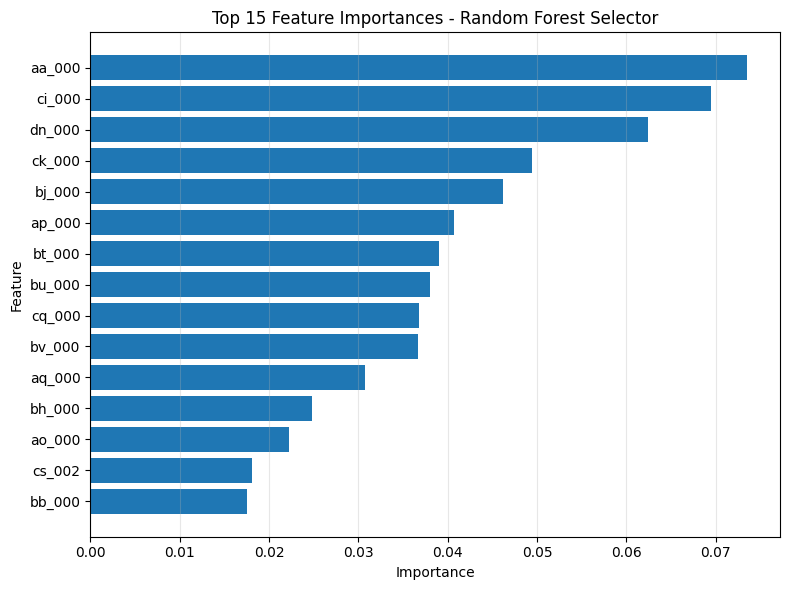

In [8]:
top_features_plot = feature_importance.head(15).sort_values(by='importance')
plt.figure(figsize=(8, 6))
plt.barh(top_features_plot['feature'], top_features_plot['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Random Forest Selector')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_feature_importances.png', dpi=300, bbox_inches='tight')
plt.show()

**Conclusión de la selección de características:** Antes de modelar, se reduce el espacio de entrada a un subconjunto de variables priorizadas por Random Forest. Esto responde a la recomendación de controlar la alta dimensionalidad del dataset sin perder completamente la posibilidad de interpretar qué señales pesan más en la predicción.

## 6. Definicion de modelos y estrategias de desbalance

Se comparan enfoques con pesos de clase y con SMOTE. La evaluacion principal se hace con validacion cruzada estratificada.


In [9]:
def make_logistic_balanced():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ])


def make_logistic_smote():
    from imblearn.pipeline import Pipeline as ImbPipeline
    return ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', LogisticRegression(max_iter=1000)),
    ])


def make_random_forest_balanced():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


def make_catboost_balanced():
    return CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.08,
        loss_function='Logloss',
        eval_metric='PRAUC',
        auto_class_weights='Balanced',
        verbose=False,
        random_state=RANDOM_STATE,
    )


candidate_models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'Logistic_Balanced': make_logistic_balanced(),
    'Logistic_SMOTE': make_logistic_smote(),
    'RandomForest_Balanced': make_random_forest_balanced(),
    'CatBoost_Balanced': make_catboost_balanced(),
}

selected_features[:10], len(selected_features)

(['aa_000',
  'ci_000',
  'dn_000',
  'ck_000',
  'bj_000',
  'ap_000',
  'bt_000',
  'bu_000',
  'cq_000',
  'bv_000'],
 30)

## 7. Validacion cruzada estratificada

La comparacion principal de modelos se realiza con validacion cruzada estratificada de 5 folds para incorporar una evaluacion mas robusta frente al desbalance.


In [10]:
X_selected = X[selected_features].copy()
X_train_selected = X_train[selected_features].copy()
X_valid_selected = X_valid[selected_features].copy()
X_official_test_selected = X_official_test[selected_features].copy()

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for model_name, model in candidate_models.items():
    fold_scores = []
    for fold_id, (train_idx, val_idx) in enumerate(cv.split(X_selected, y), start=1):
        X_fold_train = X_selected.iloc[train_idx]
        X_fold_val = X_selected.iloc[val_idx]
        y_fold_train = y.iloc[train_idx]
        y_fold_val = y.iloc[val_idx]

        model.fit(X_fold_train, y_fold_train)
        fold_predictions = np.asarray(model.predict(X_fold_val)).ravel()
        fold_summary = summarize_predictions(y_fold_val, fold_predictions)

        if model_name != 'Dummy':
            fold_scores_proba = get_probabilities(model, X_fold_val)
            avg_precision = average_precision_score((y_fold_val == POSITIVE_LABEL).astype(int), fold_scores_proba)
        else:
            avg_precision = np.nan

        fold_scores.append({
            'fold': fold_id,
            'accuracy': fold_summary['accuracy'],
            'f1_macro': fold_summary['f1_macro'],
            'precision_pos': fold_summary['precision_pos'],
            'recall_pos': fold_summary['recall_pos'],
            'f1_pos': fold_summary['f1_pos'],
            'avg_precision_pos': avg_precision,
            'cost': fold_summary['cost'],
        })

    fold_df = pd.DataFrame(fold_scores)
    cv_rows.append({
        'model': model_name,
        'accuracy': fold_df['accuracy'].mean(),
        'f1_macro': fold_df['f1_macro'].mean(),
        'precision_pos': fold_df['precision_pos'].mean(),
        'recall_pos': fold_df['recall_pos'].mean(),
        'f1_pos': fold_df['f1_pos'].mean(),
        'avg_precision_pos': fold_df['avg_precision_pos'].mean(),
        'cost': fold_df['cost'].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(by='cost').reset_index(drop=True)
save_dataframe(cv_results, 'model_summary.csv')
cv_results.round(4)

,model,accuracy,f1_macro,precision_pos,recall_pos,f1_pos,avg_precision_pos,cost
0,Logistic_SMOTE,0.9682,0.7345,0.3325,0.899,0.4854,0.5994,13712.0
1,Logistic_Balanced,0.9667,0.7284,0.3218,0.900,0.4740,0.5788,13796.0
2,CatBoost_Balanced,0.9794,0.7882,0.4415,0.876,0.5869,0.7345,14624.0
3,RandomForest_Balanced,0.9897,0.8025,0.8232,0.486,0.6102,0.7579,51610.0
4,Dummy,0.9833,0.4958,0.0000,0.000,0.0000,NaN,100000.0


**Conclusión de la validación cruzada:** La comparación metodológica ya no depende de una sola partición interna. Aquí se contrasta explícitamente el efecto de `class_weight`, `SMOTE` y modelos basados en árboles o boosting. El modelo seleccionado será el que muestre mejor balance entre recuperación de la clase positiva y costo promedio en validación cruzada.

## 8. Seleccion del modelo final

In [11]:
selected_model_name = cv_results.iloc[0]['model']
selected_model_name

'Logistic_SMOTE'

In [12]:
final_model = candidate_models[selected_model_name]
final_model.fit(X_train_selected, y_train)

valid_predictions = np.asarray(final_model.predict(X_valid_selected)).ravel()
valid_scores = get_probabilities(final_model, X_valid_selected) if selected_model_name != 'Dummy' else np.zeros(len(X_valid_selected))
valid_summary = summarize_predictions(y_valid, valid_predictions)

valid_summary

{'accuracy': 0.9675,
 'f1_macro': 0.7350303469517167,
 'precision_pos': 0.33035714285714285,
 'recall_pos': 0.925,
 'f1_pos': 0.4868421052631579,
 'cm': array([[11425,   375],
        [   15,   185]]),
 'cost': np.int64(11250)}

**Conclusión de la selección del modelo:** El modelo final se define con base en costo promedio en validación cruzada, manteniendo métricas útiles sobre la clase positiva. Esto hace que la selección sea más sólida que elegir un modelo solo por desempeño en una partición puntual.

## 9. Curva precision-recall del modelo final

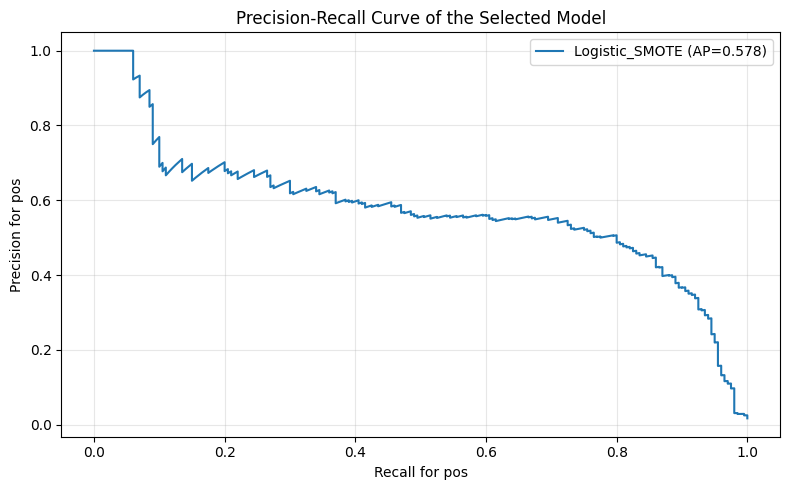

In [13]:
y_valid_pos = (y_valid == POSITIVE_LABEL).astype(int)
precision_curve, recall_curve, _ = precision_recall_curve(y_valid_pos, valid_scores)
avg_precision_valid = average_precision_score(y_valid_pos, valid_scores)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, label=f'{selected_model_name} (AP={avg_precision_valid:.3f})')
plt.xlabel('Recall for pos')
plt.ylabel('Precision for pos')
plt.title('Precision-Recall Curve of the Selected Model')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Seleccion de umbral por costo

In [14]:
threshold_rows = []
for threshold in np.arange(0.10, 0.95, 0.05):
    preds = np.where(valid_scores >= threshold, POSITIVE_LABEL, NEGATIVE_LABEL)
    summary = summarize_predictions(y_valid, preds)
    threshold_rows.append({
        'threshold': round(float(threshold), 2),
        'precision_pos': summary['precision_pos'],
        'recall_pos': summary['recall_pos'],
        'f1_pos': summary['f1_pos'],
        'cost': summary['cost'],
    })

threshold_results = pd.DataFrame(threshold_rows).sort_values(by='cost').reset_index(drop=True)
best_threshold = float(threshold_results.iloc[0]['threshold'])
save_dataframe(threshold_results, 'threshold_results.csv')
threshold_results.head(10)

,threshold,precision_pos,recall_pos,f1_pos,cost
0,0.40,0.291022,0.940,0.444444,10580
1,0.35,0.270774,0.945,0.420935,10590
2,0.30,0.247382,0.945,0.392116,11250
3,0.50,0.330357,0.925,0.486842,11250
4,0.25,0.218786,0.955,0.356011,11320
5,0.55,0.347826,0.920,0.504801,11450
6,0.45,0.311973,0.925,0.466583,11580
7,0.60,0.359841,0.905,0.514936,12720
8,0.20,0.182775,0.955,0.306827,13040
9,0.65,0.378436,0.895,0.531947,13440


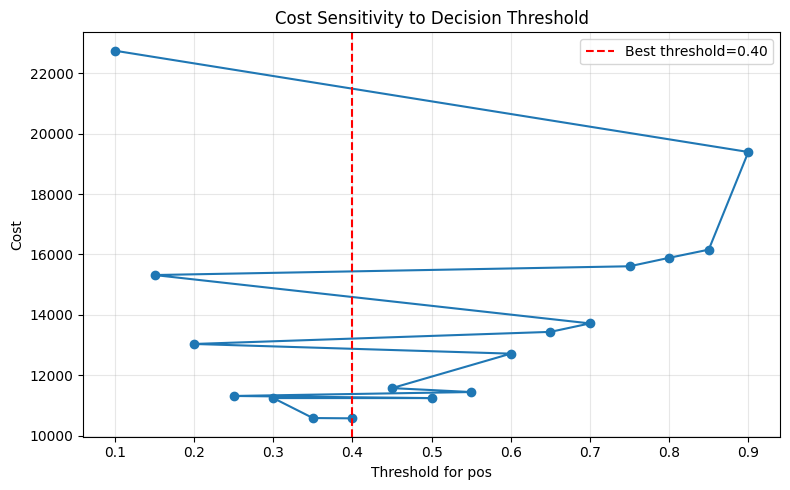

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results['threshold'], threshold_results['cost'], marker='o')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold for pos')
plt.ylabel('Cost')
plt.title('Cost Sensitivity to Decision Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cost_vs_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

**Conclusión de la selección de umbral:** Incluso con un modelo seleccionado de forma más rigurosa, el umbral por defecto no necesariamente minimiza el costo operativo. Por eso la decisión final del sistema incluye una etapa explícita de calibración de umbral.

## 11. Comparacion entre umbral por defecto y umbral optimizado

In [16]:
default_preds = np.where(valid_scores >= 0.50, POSITIVE_LABEL, NEGATIVE_LABEL)
best_preds = np.where(valid_scores >= best_threshold, POSITIVE_LABEL, NEGATIVE_LABEL)

default_summary = summarize_predictions(y_valid, default_preds)
best_summary = summarize_predictions(y_valid, best_preds)

threshold_comparison = pd.DataFrame([
    {
        'decision_rule': f'{selected_model_name} threshold 0.50',
        'threshold': 0.50,
        'accuracy': default_summary['accuracy'],
        'f1_macro': default_summary['f1_macro'],
        'precision_pos': default_summary['precision_pos'],
        'recall_pos': default_summary['recall_pos'],
        'f1_pos': default_summary['f1_pos'],
        'cost': default_summary['cost'],
    },
    {
        'decision_rule': f'{selected_model_name} best threshold',
        'threshold': best_threshold,
        'accuracy': best_summary['accuracy'],
        'f1_macro': best_summary['f1_macro'],
        'precision_pos': best_summary['precision_pos'],
        'recall_pos': best_summary['recall_pos'],
        'f1_pos': best_summary['f1_pos'],
        'cost': best_summary['cost'],
    },
])

save_dataframe(threshold_comparison, 'threshold_comparison_internal.csv')
threshold_comparison.round(4)

,decision_rule,threshold,accuracy,f1_macro,precision_pos,recall_pos,f1_pos,cost
0,Logistic_SMOTE threshold 0.50,0.5,0.9675,0.7350,0.3304,0.925,0.4868,11250
1,Logistic_SMOTE best threshold,0.4,0.9608,0.7121,0.2910,0.940,0.4444,10580


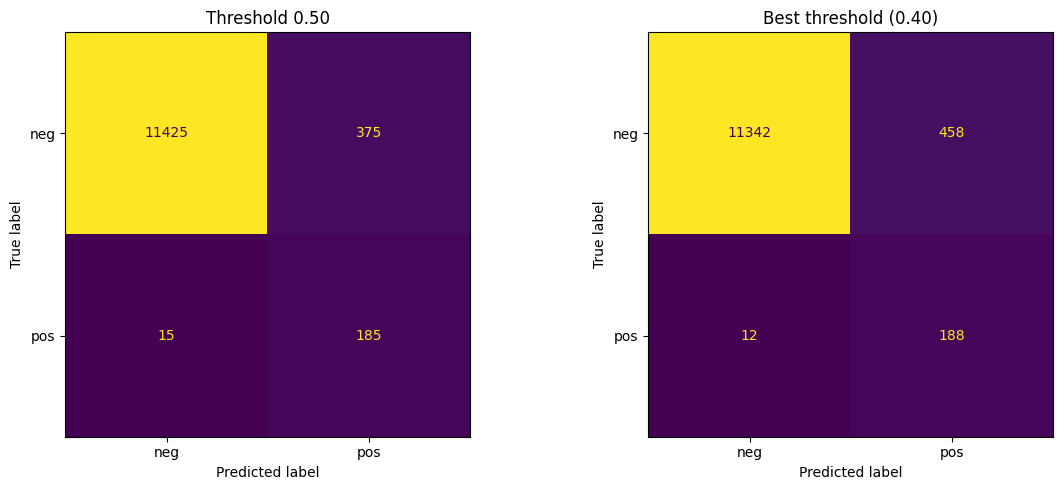

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(default_summary['cm'], display_labels=[NEGATIVE_LABEL, POSITIVE_LABEL]).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Threshold 0.50')
ConfusionMatrixDisplay(best_summary['cm'], display_labels=[NEGATIVE_LABEL, POSITIVE_LABEL]).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Best threshold ({best_threshold:.2f})')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'threshold_comparison_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

**Conclusión de la comparación de umbrales:** El umbral optimizado reduce el costo y aumenta el `recall` de la clase positiva, aunque típicamente sacrifica algo de precisión. Esto es consistente con una estrategia de priorización, donde interesa minimizar el riesgo de no detectar una falla realmente costosa.

## 12. Validacion final sobre el conjunto oficial de prueba

In [18]:
final_model.fit(X[selected_features], y)
joblib.dump(final_model, MODELS_DIR / 'scania_selected_model.joblib')

official_scores = get_probabilities(final_model, X_official_test_selected)
official_preds_default = np.where(official_scores >= 0.50, POSITIVE_LABEL, NEGATIVE_LABEL)
official_preds_best = np.where(official_scores >= best_threshold, POSITIVE_LABEL, NEGATIVE_LABEL)

official_default_summary = summarize_predictions(y_official_test, official_preds_default)
official_best_summary = summarize_predictions(y_official_test, official_preds_best)

official_test_results = pd.DataFrame([
    {
        'decision_rule': 'Official test - threshold 0.50',
        'threshold': 0.50,
        'accuracy': official_default_summary['accuracy'],
        'f1_macro': official_default_summary['f1_macro'],
        'precision_pos': official_default_summary['precision_pos'],
        'recall_pos': official_default_summary['recall_pos'],
        'f1_pos': official_default_summary['f1_pos'],
        'cost': official_default_summary['cost'],
    },
    {
        'decision_rule': 'Official test - best threshold',
        'threshold': best_threshold,
        'accuracy': official_best_summary['accuracy'],
        'f1_macro': official_best_summary['f1_macro'],
        'precision_pos': official_best_summary['precision_pos'],
        'recall_pos': official_best_summary['recall_pos'],
        'f1_pos': official_best_summary['f1_pos'],
        'cost': official_best_summary['cost'],
    },
])

save_dataframe(official_test_results, 'official_test_results.csv')
official_test_results.round(4)

,decision_rule,threshold,accuracy,f1_macro,precision_pos,recall_pos,f1_pos,cost
0,Official test - threshold 0.50,0.5,0.9698,0.7845,0.4315,0.9067,0.5847,21980
1,Official test - best threshold,0.4,0.9638,0.7629,0.3860,0.9253,0.5447,19520


**Conclusión de la validación final:** El modelo y la regla de decisión se someten a una prueba adicional en el conjunto oficial de Scania. Esto fortalece la validez del proyecto porque la evaluación final ya no depende solo de una partición interna o de la validación cruzada.

## 13. Salida de priorizacion para la capa de aplicacion

In [19]:
prioritization_table = test_df.copy().reset_index().rename(columns={'index': 'record_id'})
prioritization_table['failure_score'] = official_scores
prioritization_table['predicted_class'] = np.where(official_scores >= best_threshold, POSITIVE_LABEL, NEGATIVE_LABEL)

prioritization_table['priority_level'] = pd.cut(
    prioritization_table['failure_score'],
    bins=[-0.01, best_threshold, 0.50, 1.00],
    labels=['baja', 'media', 'alta'],
)

action_map = {
    'alta': 'inspeccion inmediata',
    'media': 'revision programada',
    'baja': 'seguimiento rutinario',
}
prioritization_table['recommended_action'] = prioritization_table['priority_level'].astype(str).map(action_map)

prioritization_output = prioritization_table[[
    'record_id',
    TARGET_COLUMN,
    'failure_score',
    'predicted_class',
    'priority_level',
    'recommended_action',
]]\
    .sort_values(by='failure_score', ascending=False)

save_dataframe(prioritization_output, 'prioritization_output.csv')
prioritization_output.head(15)

,record_id,class,failure_score,predicted_class,priority_level,recommended_action
8750,8750,pos,1.0,pos,alta,inspeccion inmediata
4935,4935,pos,1.0,pos,alta,inspeccion inmediata
42,42,pos,1.0,pos,alta,inspeccion inmediata
5069,5069,pos,1.0,pos,alta,inspeccion inmediata
13897,13897,pos,1.0,pos,alta,inspeccion inmediata
6738,6738,pos,1.0,pos,alta,inspeccion inmediata
5246,5246,neg,1.0,pos,alta,inspeccion inmediata
4694,4694,pos,1.0,pos,alta,inspeccion inmediata
5977,5977,pos,1.0,pos,alta,inspeccion inmediata
2284,2284,pos,1.0,pos,alta,inspeccion inmediata


**Conclusión de la salida de priorización:** El proyecto ya no se detiene en una predicción binaria. A partir del score, el umbral y la categoría de prioridad, se obtiene una tabla directamente utilizable por una mini aplicación o dashboard de apoyo a decisiones de mantenimiento.

## 14. Resumen ejecutivo del notebook

In [20]:
final_notebook_summary = pd.DataFrame([
    {'item': 'selected_model', 'value': selected_model_name},
    {'item': 'feature_selection_strategy', 'value': f'RandomForest top {TOP_K_FEATURES}'},
    {'item': 'best_threshold_by_cost', 'value': round(best_threshold, 2)},
    {'item': 'internal_cost_default_threshold', 'value': default_summary['cost']},
    {'item': 'internal_cost_best_threshold', 'value': best_summary['cost']},
    {'item': 'official_cost_default_threshold', 'value': official_default_summary['cost']},
    {'item': 'official_cost_best_threshold', 'value': official_best_summary['cost']},
    {'item': 'official_precision_pos_best_threshold', 'value': official_best_summary['precision_pos']},
    {'item': 'official_recall_pos_best_threshold', 'value': official_best_summary['recall_pos']},
    {'item': 'official_f1_pos_best_threshold', 'value': official_best_summary['f1_pos']},
    {'item': 'most_important_feature', 'value': feature_importance.iloc[0]['feature']},
])

save_dataframe(final_notebook_summary, 'final_notebook_summary.csv')
final_notebook_summary

,item,value
0,selected_model,Logistic_SMOTE
1,feature_selection_strategy,RandomForest top 30
2,best_threshold_by_cost,0.4
3,internal_cost_default_threshold,11250
4,internal_cost_best_threshold,10580
5,official_cost_default_threshold,21980
6,official_cost_best_threshold,19520
7,official_precision_pos_best_threshold,0.385984
8,official_recall_pos_best_threshold,0.925333
9,official_f1_pos_best_threshold,0.544741


**Conclusión final del notebook:** La base técnica del proyecto queda fortalecida con selección de características, manejo explícito del desbalance, validación cruzada estratificada, calibración por costo y validación final en el test oficial. A partir de aquí, el proyecto puede avanzar con mayor respaldo metodológico hacia el documento académico y la consolidación de la aplicación ligera.